## Decision Trees in Machine Learning

Decision trees are a popular and intuitive supervised machine learning algorithm used for both classification and regression tasks. They work by partitioning the data into subsets based on the values of input features, forming a tree-like structure of decisions. Each internal node in the tree represents a "test" on an attribute (e.g., is age > 30?), each branch represents the outcome of the test, and each leaf node represents a class label (in classification) or a numerical value (in regression).

Here's a detailed breakdown of how they work and their key characteristics:

**1. Basic Structure:**
*   **Root Node:** The topmost node of the tree, representing the entire dataset. The first split happens here.
*   **Internal Nodes (Decision Nodes):** Nodes that have branches leading to other nodes. Each internal node represents a decision rule based on a feature, splitting the data into subsets.
*   **Branches (Edges):** Connect nodes and represent the outcome of a decision.
*   **Leaf Nodes (Terminal Nodes):** Nodes that do not split further. They contain the final prediction or classification.

**2. How Decision Trees Learn (Splitting Criteria):**
The core idea is to find the "best" way to split the data at each node. The algorithm iteratively selects the feature and the split point that best divides the data into more homogeneous subsets. This process is greedy, meaning it makes the best local decision at each step without necessarily considering the global optimum.

Common splitting criteria include:
*   **Gini Impurity (for classification):** Measures the probability of a randomly chosen element being incorrectly classified if it were randomly labeled according to the distribution of labels in the subset. A Gini impurity of 0 means all elements belong to the same class (perfectly pure).
*   **Information Gain (for classification):** Based on entropy, which measures the impurity or randomness of a set of examples. Information gain quantifies the reduction in entropy achieved by a split. The algorithm aims to maximize information gain.
*   **Variance Reduction (for regression):** Measures the reduction in variance of the target variable after a split. The goal is to minimize the variance within each resulting subset.

**3. Tree Building Process (ID3, C4.5, CART):**
*   **Start with the Root Node:** All data points are at the root.
*   **Select Best Split:** The algorithm evaluates all possible splits for all features and chooses the one that maximizes information gain (or minimizes Gini impurity/variance).
*   **Create Child Nodes:** Based on the chosen split, the data is divided into subsets, and child nodes are created.
*   **Repeat:** This process is recursively applied to each child node until a stopping condition is met.

**4. Stopping Conditions (When to Stop Splitting):**
To prevent overfitting, the tree building process is usually stopped when:
*   All data points in a node belong to the same class (pure node).
*   The number of data points in a node falls below a predefined threshold (`min_samples_split`).
*   The tree reaches a maximum depth (`max_depth`).
*   The improvement in impurity after a split falls below a certain threshold (`min_impurity_decrease`).

**5. Pruning:**
After a tree is fully grown, it might be overly complex and overfit the training data. Pruning techniques are used to simplify the tree by removing branches that have little predictive power on unseen data.
*   **Pre-pruning (Early Stopping):** Stopping the tree growth early based on the stopping conditions mentioned above.
*   **Post-pruning:** Growing a full tree and then removing branches (nodes) that do not contribute significantly to generalization performance, typically using a validation set.

**6. Advantages of Decision Trees:**
*   **Easy to Understand and Interpret:** The tree structure is very intuitive and can be visualized, making it easy to explain to non-technical stakeholders.
*   **Handle Both Numerical and Categorical Data:** They don't require feature scaling or normalization.
*   **Non-linear Relationships:** Can capture complex non-linear relationships between features and the target variable.
*   **Minimal Data Preprocessing:** Less data cleaning and preparation required compared to some other algorithms.

**7. Disadvantages of Decision Trees:**
*   **Prone to Overfitting:** Without proper pruning or limiting tree depth, they can easily overfit the training data, leading to poor generalization on new data.
*   **Instability:** Small changes in the training data can lead to a completely different tree structure.
*   **Bias towards Dominant Classes:** Can be biased towards features with more levels or dominant classes if not handled carefully.
*   **Sub-optimal Splits (Greedy Approach):** The greedy nature of the splitting algorithm means it doesn't always find the globally optimal tree.

**8. Ensemble Methods for Decision Trees:**
To overcome some of the disadvantages, especially overfitting and instability, decision trees are often used as base estimators in ensemble methods:
*   **Random Forests:** Builds multiple decision trees on different subsets of the data and features, and then averages their predictions (for regression) or uses majority voting (for classification). This significantly reduces variance and improves robustness.
*   **Gradient Boosting (e.g., XGBoost, LightGBM, CatBoost):** Builds trees sequentially, where each new tree tries to correct the errors of the previous ones. This focuses on reducing bias.

In summary, decision trees are fundamental machine learning algorithms that provide a clear, interpretable way to model decisions. While they have limitations on their own, they form the basis for some of the most powerful and widely used ensemble models in machine learning.

In [1]:
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier, export_graphviz
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
# Optional: for visualizing the tree
from IPython.display import Image
import graphviz

### 1. Load and Prepare the Data
We'll use the Iris dataset, which is a classic for classification tasks.

In [2]:
# Load the Iris dataset
iris = load_iris()
X = iris.data
y = iris.target

# Create a DataFrame for better readability (optional)
iris_df = pd.DataFrame(X, columns=iris.feature_names)
iris_df['species'] = iris.target_names[y]

print("First 5 rows of the Iris dataset:")
display(iris_df.head())
print("\nTarget classes:", iris.target_names)

First 5 rows of the Iris dataset:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa



Target classes: ['setosa' 'versicolor' 'virginica']


### 2. Split Data into Training and Testing Sets
It's crucial to split your data to evaluate how well your model generalizes to unseen data.

In [3]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print(f"Training set size: {len(X_train)} samples")
print(f"Testing set size: {len(X_test)} samples")

Training set size: 105 samples
Testing set size: 45 samples


### 3. Initialize and Train the Decision Tree Model
We'll use `DecisionTreeClassifier` from `sklearn.tree`. We can specify parameters like `max_depth` to control the tree's complexity and prevent overfitting.

In [4]:
# Initialize the Decision Tree Classifier
# max_depth limits the tree depth to prevent overfitting
dtree_classifier = DecisionTreeClassifier(max_depth=3, random_state=42)

# Train the model on the training data
dtree_classifier.fit(X_train, y_train)

print("Decision Tree Classifier trained successfully!")

Decision Tree Classifier trained successfully!


### 4. Make Predictions
Now, let's use our trained model to predict the species for the test set.

In [5]:
y_pred = dtree_classifier.predict(X_test)

print("First 10 actual labels:", y_test[:10])
print("First 10 predicted labels:", y_pred[:10])

First 10 actual labels: [1 0 2 1 1 0 1 2 1 1]
First 10 predicted labels: [1 0 2 1 1 0 1 2 1 1]


### 5. Evaluate the Model
We'll check the accuracy and a detailed classification report to understand the model's performance.

In [6]:
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=iris.target_names))

Accuracy: 1.00

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        19
  versicolor       1.00      1.00      1.00        13
   virginica       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45



### 6. Visualize the Decision Tree (Optional)
Visualizing the tree helps in understanding the decision-making process. This requires `graphviz` to be installed (which is usually available in Colab).

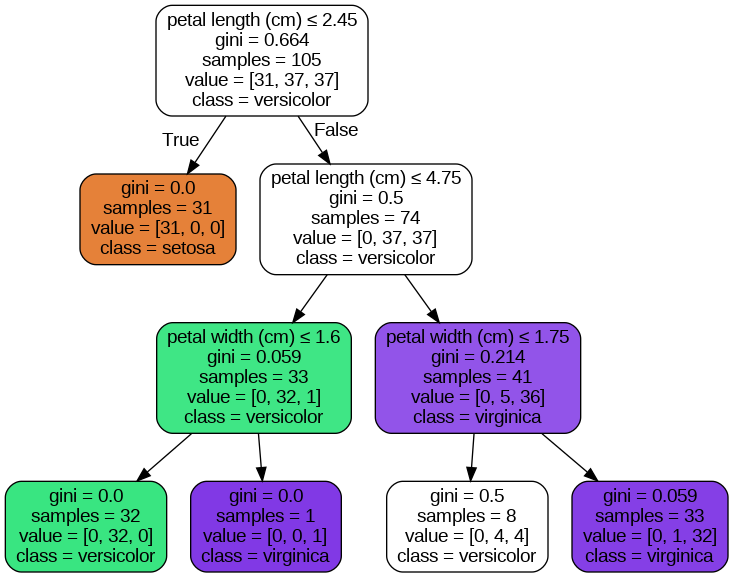

In [7]:
# Export the trained decision tree to a DOT file
dot_data = export_graphviz(dtree_classifier,
                           out_file=None,
                           feature_names=iris.feature_names,
                           class_names=iris.target_names,
                           filled=True, rounded=True,
                           special_characters=True)

# Render the DOT graph using graphviz
graph = graphviz.Source(dot_data)
graph.render("iris_decision_tree", view=True, format='png') # This saves to a file and tries to open it

# To display it directly in the notebook (requires graphviz and IPython.display.Image)
Image(graph.pipe(format='png'))

#Program 1: Student Pass or Fail Prediction (Beginner)

In [8]:
from sklearn.tree import DecisionTreeClassifier

# Features:
# [Study Hours, Attendance (%)]

X = [
    [2, 50],
    [3, 60],
    [4, 65],
    [5, 70],
    [6, 75],
    [7, 80],
    [8, 90],
    [9, 95]
]

# 0 = Fail
# 1 = Pass

y = [0, 0, 0, 1, 1, 1, 1, 1]

model = DecisionTreeClassifier()

model.fit(X, y)

study_hours = int(input("Enter Study Hours: "))
attendance = int(input("Enter Attendance (%): "))

prediction = model.predict([[study_hours, attendance]])

if prediction[0] == 1:
    print("Pass")
else:
    print("Fail")

Enter Study Hours: 5
Enter Attendance (%): 85
Pass


#Program 2: Weather-Based Picnic Prediction

In [9]:
from sklearn.tree import DecisionTreeClassifier

# Features:
# [Temperature, Humidity]

X = [
    [20, 40],
    [22, 45],
    [24, 50],
    [26, 60],
    [28, 70],
    [30, 80],
    [32, 85],
    [34, 90]
]

# 0 = Don't Go
# 1 = Go

y = [1, 1, 1, 1, 0, 0, 0, 0]

model = DecisionTreeClassifier()

model.fit(X, y)

temperature = int(input("Temperature: "))
humidity = int(input("Humidity: "))

prediction = model.predict([[temperature, humidity]])

if prediction[0] == 1:
    print("Go for Picnic")
else:
    print("Stay Home")

Temperature: 45
Humidity: 66
Stay Home


#College Admission Prediction (Marks, Entrance Score, Interview Score)

Enter Marks: 69
Enter Entrance Score: 55
Enter Interview Score: 95

Admission Rejected


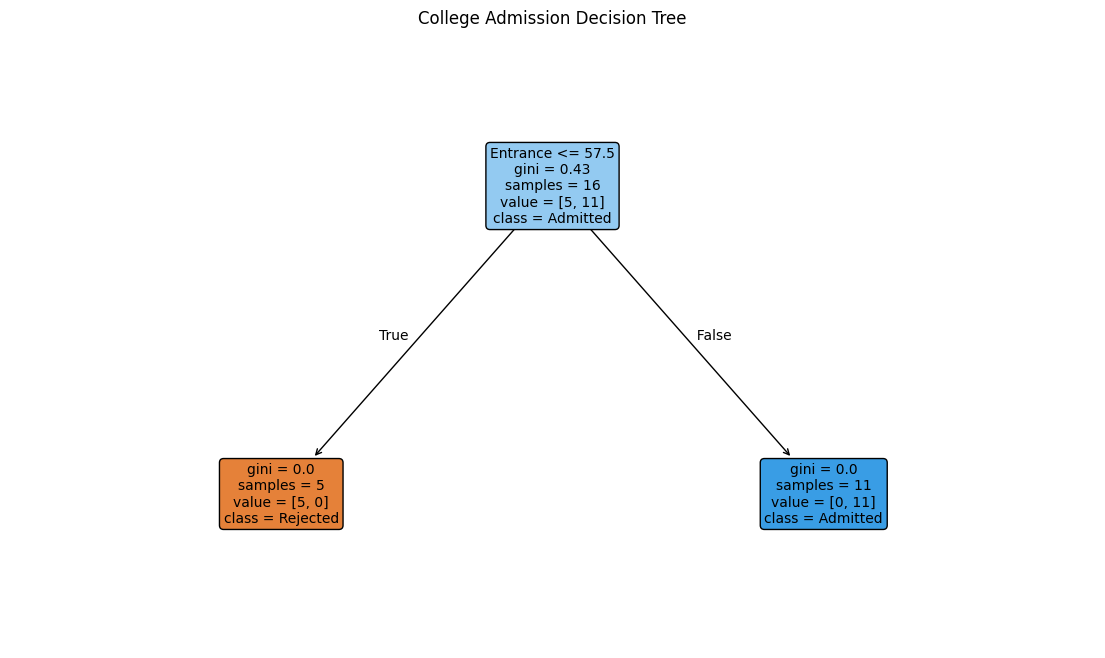

In [10]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

# -----------------------------
# Dataset
# Features:
# [Marks, Entrance Score, Interview Score]
# -----------------------------

X = [
    [45, 40, 30],
    [50, 45, 35],
    [55, 50, 40],
    [60, 55, 50],
    [65, 60, 55],
    [70, 65, 60],
    [75, 70, 65],
    [80, 75, 70],
    [85, 80, 75],
    [90, 85, 80],
    [92, 88, 85],
    [95, 90, 90],
    [97, 95, 95],
    [78, 72, 68],
    [58, 52, 45],
    [68, 62, 58],
]

# 0 = Rejected
# 1 = Admitted

y = [
    0,
    0,
    0,
    0,
    1,
    1,
    1,
    1,
    1,
    1,
    1,
    1,
    1,
    1,
    0,
    1
]

# -----------------------------
# Create Model
# -----------------------------

model = DecisionTreeClassifier(
    criterion="gini",
    max_depth=3,
    random_state=42
)

model.fit(X, y)

# -----------------------------
# Prediction
# -----------------------------

marks = int(input("Enter Marks: "))
entrance = int(input("Enter Entrance Score: "))
interview = int(input("Enter Interview Score: "))

prediction = model.predict([[marks, entrance, interview]])

if prediction[0] == 1:
    print("\nAdmission Approved")
else:
    print("\nAdmission Rejected")

# -----------------------------
# Tree Visualization
# -----------------------------

plt.figure(figsize=(14,8))

plot_tree(
    model,
    feature_names=["Marks", "Entrance", "Interview"],
    class_names=["Rejected", "Admitted"],
    filled=True,
    rounded=True,
    fontsize=10
)

plt.title("College Admission Decision Tree")
plt.show()